In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision as vision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

import numpy as np

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from helper_functions import *

import kagglehub as kg

from tqdm.auto import tqdm # Progress bar
from pathlib import Path
import zipfile
from PIL import Image
import random

torch.set_default_device("cpu")

print(f"Torch: {torch.__version__}")
print(f"TorchVision: {torchvision.__version__}")
print(f"KaggleHub: {kg.__version__}")

!nvidia-smi

Torch: 2.8.0
TorchVision: 0.23.0
KaggleHub: 0.3.13
zsh:1: command not found: nvidia-smi


In [3]:
data_path = Path("./")
image_path = data_path / Path("pizza_steak_sushi")
if image_path.is_dir():
    print("Images already downloaded")

Images already downloaded


In [4]:
# We need to cretate a custom dataset e we need to perform some transformations on the data
# Lets try FoodVisionMini

# Load custom data
# We need to transform data into tensors
import os
def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories {len(filenames)}")

In [5]:
walk_through_dir("pizza_steak_sushi")

There are 2 directories 0
There are 3 directories 0
There are 0 directories 250
There are 0 directories 250
There are 0 directories 250
There are 3 directories 0
There are 0 directories 750
There are 0 directories 750
There are 0 directories 750


In [6]:
train_dir = image_path / "train"
test_dir = image_path / "test"
train_dir, test_dir

(PosixPath('pizza_steak_sushi/train'), PosixPath('pizza_steak_sushi/test'))

In [7]:
# Lets visualize the data
random.seed(42)

# Pattern for selecting the names
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('pizza_steak_sushi/test/steak/413497.jpg'),
 PosixPath('pizza_steak_sushi/test/steak/2246332.jpg'),
 PosixPath('pizza_steak_sushi/test/steak/2649745.jpg'),
 PosixPath('pizza_steak_sushi/test/steak/2382600.jpg'),
 PosixPath('pizza_steak_sushi/test/steak/296375.jpg'),
 PosixPath('pizza_steak_sushi/test/steak/2484823.jpg'),
 PosixPath('pizza_steak_sushi/test/steak/400951.jpg'),
 PosixPath('pizza_steak_sushi/test/steak/285269.jpg'),
 PosixPath('pizza_steak_sushi/test/steak/2475366.jpg'),
 PosixPath('pizza_steak_sushi/test/steak/1982192.jpg')]

R image path: pizza_steak_sushi/train/pizza/3281494.jpg
R image class: pizza
R image dim: 288 512


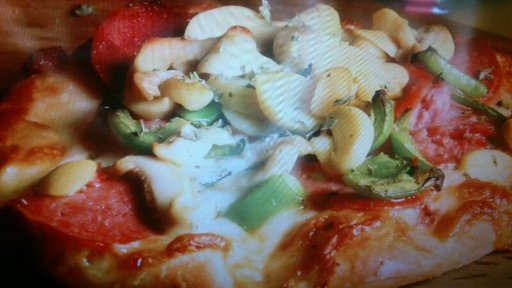

In [8]:
# Open image
random_image_path = random.choice(image_path_list)
image_class = random_image_path.parent.stem
img = Image.open(random_image_path)
print(f"R image path: {random_image_path}")
print(f"R image class: {image_class}")
print(f"R image dim: {img.height} {img.width}")
img

Text(0.5, 1.0, 'Class: pizza | shape: (288, 512, 3) | h X w: 288 X 512')

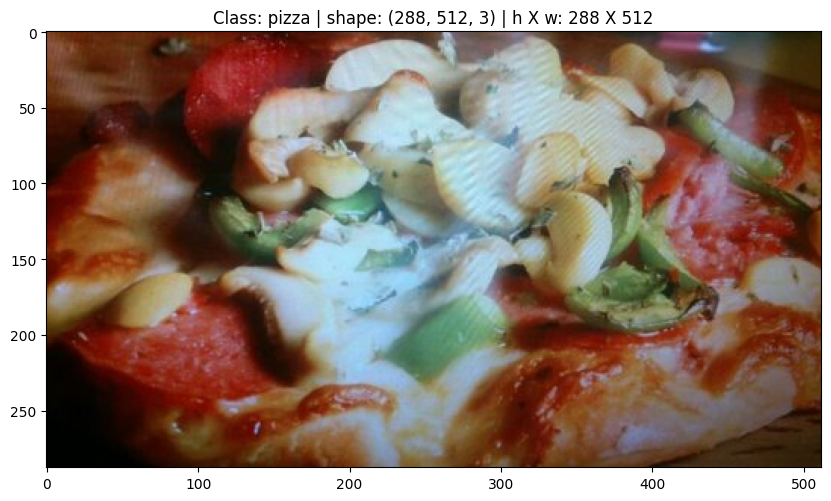

In [9]:
# Tunn image into array
img_as_array = np.asarray(img)
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Class: {image_class} | shape: {img_as_array.shape} | h X w: {img.height} X {img.width}")

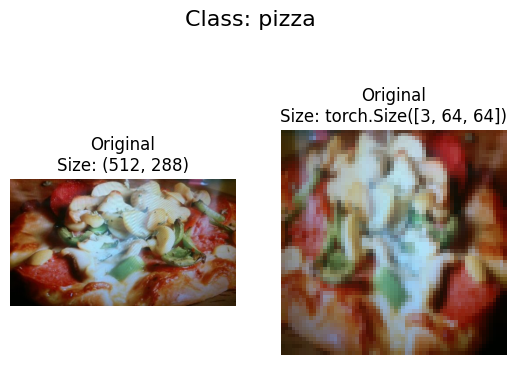

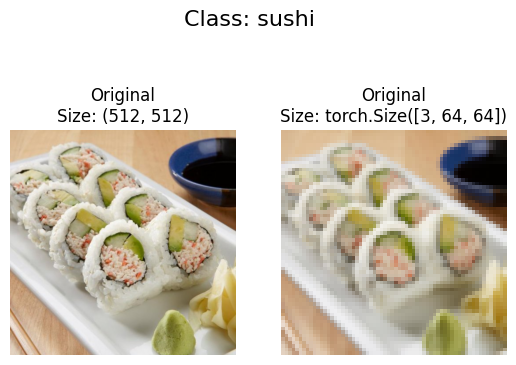

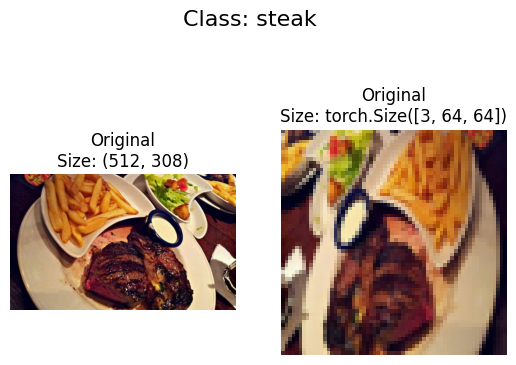

In [10]:
# Transforming data
# We need to trasform data into tensors
# From data -> dataset -> dataloader
data_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)), # This is standardizing the size
    # of the image
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor()
])

trasfo_img = data_transforms(img)

def plot_trasformed_images(image_paths : list, transforms, n = 3, seed = 42):
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k = n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize: {f.size}")
            ax[0].axis(False)

            # Transform image
            transformed_img = transforms(f)
            ax[1].imshow(transformed_img.permute(1, 2, 0))
            ax[1].set_title(f"Original\nSize: {transformed_img.shape}")
            ax[1].axis(False)

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_trasformed_images(image_paths=image_path_list, transforms=data_transforms)        

In [11]:
# Load datasets
train_dataset = torchvision.datasets.ImageFolder(train_dir, 
                                 transform=data_transforms, # Trasform for the data
                                 target_transform=None) # Trasform for the labels
test_dataset = torchvision.datasets.ImageFolder(test_dir, 
                                 transform=data_transforms, # Trasform for the data
                                 target_transform=None)

train_dataset, test_dataset

(Dataset ImageFolder
     Number of datapoints: 2250
     Root location: pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 750
     Root location: pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [12]:
class_names = train_dataset.classes
class_dict = train_dataset.class_to_idx
class_names, class_dict

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [13]:
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(train_dataloader)

In [14]:
train_features_batch, train_label_batch = next(iter(train_dataloader))
test_features_batch, test_label_betch = next(iter(test_dataloader))
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_label_batch[random_idx]
# plt.imshow(img.permute(1, 2, 0))
# plt.title(class_names[label])
# plt.axis(False)

In [15]:
from helper_functions import accuracy_fn as not_my_acc_fn

# Create a function to time out experiments
from timeit import default_timer as timer

def print_train_time(start : float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")

def train_model(model: nn.Module, loss_fn, optimizer, train_dataloader, epochs, accuracy_fn):
    # # Training on batches
   
    torch.manual_seed(42)
    start = timer()
    for ep in tqdm(range(epochs)):
        train_loss = 0
        train_acc = 0
        model.train()
        for batch, (X, y) in enumerate(train_dataloader):
            # Logits
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            train_loss += loss
            acc = accuracy_fn(y, y_pred=y_pred.argmax(dim=1))
            train_acc += acc

            # Zero Grad
            optimizer.zero_grad()
            # backpropagation
            loss.backward()
            # This is doint once per batch
            optimizer.step()

        # Device train loass
        train_acc /= len(train_dataloader)
        train_loss /= len(train_dataloader)

        print(f"Epoch: {ep} | TrainLoss: {train_loss}, TrainAcc : {train_acc}")    

    end = timer()
    return model

def eval_model(model, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, acc_fn):
    loss, acc = 0, 0
    model.eval()
    test_loss = 0.0
    test_acc = 0
    len_l = len(data_loader)
    with torch.inference_mode():
        for X_test, y_test in data_loader:
            test_pred = model(X_test)
            loss = loss_fn(test_pred, y_test)
            test_loss += loss
            acc = acc_fn(y_test, test_pred.argmax(dim=1))
            test_acc += acc
            
    test_loss = test_loss * (1 / len_l)
    test_acc /= len_l

    return {"model_name" : model.__class__.__name__,
        "model_loss": test_loss.item(), "model_acc": test_acc}

![Just keep smiling](https://www.cs.toronto.edu/~frossard/post/vgg16/vgg16.png)

In [16]:
# CNN Model
class CNNPizza(nn.Module):
    """We are copying the TinyVGG"""
    def __init__(self, output_shape):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=3, kernel_size=5),
            nn.ReLU(),

            nn.Conv2d(in_channels=3, out_channels=3, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=3, out_channels=3, kernel_size=5),
            nn.ReLU(),
            
            nn.Conv2d(in_channels=3, out_channels=3, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(in_features=300, out_features=output_shape),
        )

    def forward(self, x):
        return self.layer_stack(x)

inf = (len(nn.Flatten()(img).squeeze()))
model_cnn_2 = CNNPizza(len(class_names))
print(model_cnn_2)

# Loss and Optim
loss_fn = nn.CrossEntropyLoss() 
optimizer = optim.SGD(params=model_cnn_2.parameters(), lr = 0.03)

# Train
my_trained_cnn_2 = train_model(model_cnn_2, loss_fn, optimizer, train_dataloader, 40, not_my_acc_fn)

CNNPizza(
  (layer_stack): Sequential(
    (0): Conv2d(3, 3, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(3, 3, kernel_size=(5, 5), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(3, 3, kernel_size=(5, 5), stride=(1, 1))
    (6): ReLU()
    (7): Conv2d(3, 3, kernel_size=(5, 5), stride=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=300, out_features=3, bias=True)
  )
)


  0%|          | 0/40 [00:00<?, ?it/s]

Epoch: 0 | TrainLoss: 1.0992307662963867, TrainAcc : 33.30105633802817
Epoch: 1 | TrainLoss: 1.0989009141921997, TrainAcc : 33.45070422535211
Epoch: 2 | TrainLoss: 1.0990151166915894, TrainAcc : 32.605633802816904
Epoch: 3 | TrainLoss: 1.0990346670150757, TrainAcc : 31.804577464788732
Epoch: 4 | TrainLoss: 1.0990594625473022, TrainAcc : 32.38556338028169
Epoch: 5 | TrainLoss: 1.0990235805511475, TrainAcc : 31.065140845070424
Epoch: 6 | TrainLoss: 1.0990543365478516, TrainAcc : 31.822183098591548
Epoch: 7 | TrainLoss: 1.0989524126052856, TrainAcc : 33.01056338028169
Epoch: 8 | TrainLoss: 1.0990207195281982, TrainAcc : 31.989436619718308
Epoch: 9 | TrainLoss: 1.098957896232605, TrainAcc : 33.62676056338028
Epoch: 10 | TrainLoss: 1.0989538431167603, TrainAcc : 33.20422535211268
Epoch: 11 | TrainLoss: 1.0990405082702637, TrainAcc : 32.17429577464789
Epoch: 12 | TrainLoss: 1.0989583730697632, TrainAcc : 32.38556338028169
Epoch: 13 | TrainLoss: 1.098989725112915, TrainAcc : 32.06866197183098

KeyboardInterrupt: 